In [8]:
#Dataset Reading
import pandas as pd

In [42]:
# Load dataset
df = pd.read_csv(r"C:\Users\lenovo\OneDrive\Desktop\Major Project\Opticom Signal quality dataset.csv")

In [41]:
# Display basic info
df.head()

,Tx,Rx,Various Points,SNR Receiver,SNR Stages,BER Receiver,BER Environmental,Modulation Format,Modulation Depth,Transmission Distance,...,Fiber Attenuation,Splice Losses,Optical Amplifier Gain,PMD Coefficient,PMD Compensation,CD Coefficient,CD Compensation,Temperature,Humidity,Signal Quality
0,10.5,15.2,12.8,23.6,22.1,0.000001,0.000002,0,0.8,20,...,0.10,0.20,10,0.05,0,0.03,0,25.0,60.0,0
1,11.2,16.5,12.6,24.2,22.8,0.000001,0.000002,1,0.7,21,...,0.11,0.22,12,0.06,0,0.04,0,26.0,61.0,0
2,9.8,14.8,12.9,23.4,21.9,0.000001,0.000001,2,0.9,19,...,0.09,0.18,9,0.04,0,0.02,0,24.0,59.0,0
3,12.1,18.2,13.2,24.8,23.5,0.000002,0.000002,0,0.8,22,...,0.12,0.24,11,0.07,0,0.05,0,27.0,62.0,0
4,10.9,15.8,13.0,24.0,22.5,0.000001,0.000002,1,0.7,20,...,0.10,0.20,10,0.05,0,0.03,0,25.0,60.0,0


In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 586 entries, 0 to 585
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Tx                      586 non-null    float64
 1   Rx                      586 non-null    float64
 2   Various Points          586 non-null    float64
 3   SNR Receiver            586 non-null    float64
 4   SNR Stages              586 non-null    float64
 5   BER Receiver            586 non-null    float64
 6   BER Environmental       586 non-null    float64
 7   Modulation Format       586 non-null    object 
 8   Modulation Depth        586 non-null    float64
 9   Transmission Distance   586 non-null    int64  
 10  Distance Between        586 non-null    int64  
 11  Fiber Attenuation       586 non-null    float64
 12  Splice Losses           586 non-null    float64
 13  Optical Amplifier Gain  586 non-null    int64  
 14  PMD Coefficient         586 non-null    fl

In [6]:
print(df['Signal Quality'].value_counts())

Signal Quality
Good    538
Poor     47
Name: count, dtype: int64


In [44]:
#Data Preprocessing
from sklearn.preprocessing import LabelEncoder

In [10]:
# Handle missing values (numeric → median)
df = df.fillna(df.median(numeric_only=True))

In [11]:
# Encode target column
label_encoder = LabelEncoder()
df['Signal Quality'] = label_encoder.fit_transform(df['Signal Quality'])

In [12]:
# Separate features and target
X = df.drop(columns=['Signal Quality'])
y = df['Signal Quality']

In [14]:
# Check data types
print(X.dtypes)

Tx                        float64
Rx                        float64
Various Points            float64
SNR Receiver              float64
SNR Stages                float64
BER Receiver              float64
BER Environmental         float64
Modulation Format          object
Modulation Depth          float64
Transmission Distance       int64
Distance Between            int64
Fiber Attenuation         float64
Splice Losses             float64
Optical Amplifier Gain      int64
PMD Coefficient           float64
PMD Compensation           object
CD Coefficient            float64
CD Compensation            object
Temperature               float64
Humidity                  float64
dtype: object


In [23]:
#to alter dummies we check which data is in object form
categorical_cols = X.select_dtypes(include=['object']).columns
print(categorical_cols)

Index(['Modulation Format', 'PMD Compensation', 'CD Compensation'], dtype='object')


In [56]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
X['Modulation Format'] = le.fit_transform(X['Modulation Format'])

In [57]:
le = LabelEncoder()
X['PMD Compensation'] = le.fit_transform(X['PMD Compensation'])

In [58]:
le = LabelEncoder()
X['CD Compensation'] = le.fit_transform(X['CD Compensation'])

In [59]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [27]:
#SMOTE Data Balancing
from imblearn.over_sampling import SMOTE

In [29]:
print(pd.Series(y).value_counts())

Signal Quality
0    538
1     47
2      1
Name: count, dtype: int64


In [50]:
# Remove classes with less than 2 samples
class_counts = y.value_counts()
valid_classes = class_counts[class_counts > 1].index

In [60]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [68]:
mask = y.isin(valid_classes)
X_filtered = X_scaled[mask]
y_filtered = y[mask]

In [67]:
smote = SMOTE(random_state=42, k_neighbors=1)
X_resampled, y_resampled = smote.fit_resample(X_filtered, y_filtered)

In [69]:
print("After SMOTE class distribution:")
print(pd.Series(y_resampled).value_counts())

After SMOTE class distribution:
Signal Quality
0    538
1    538
Name: count, dtype: int64


In [71]:
#Exploratory Data Analysis (EDA)
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


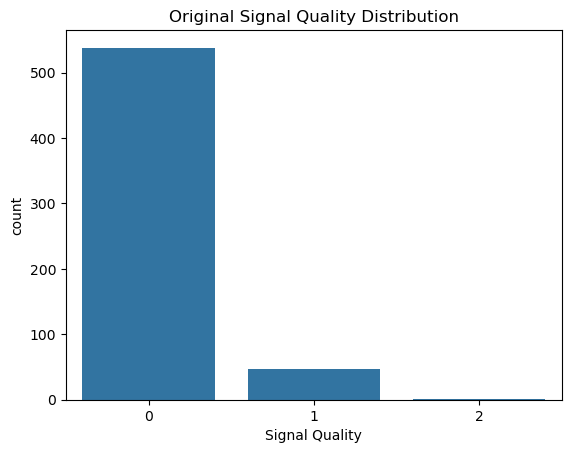

In [72]:
# Class distribution
plt.figure()
sns.countplot(x=y)
plt.title("Original Signal Quality Distribution")
plt.show()

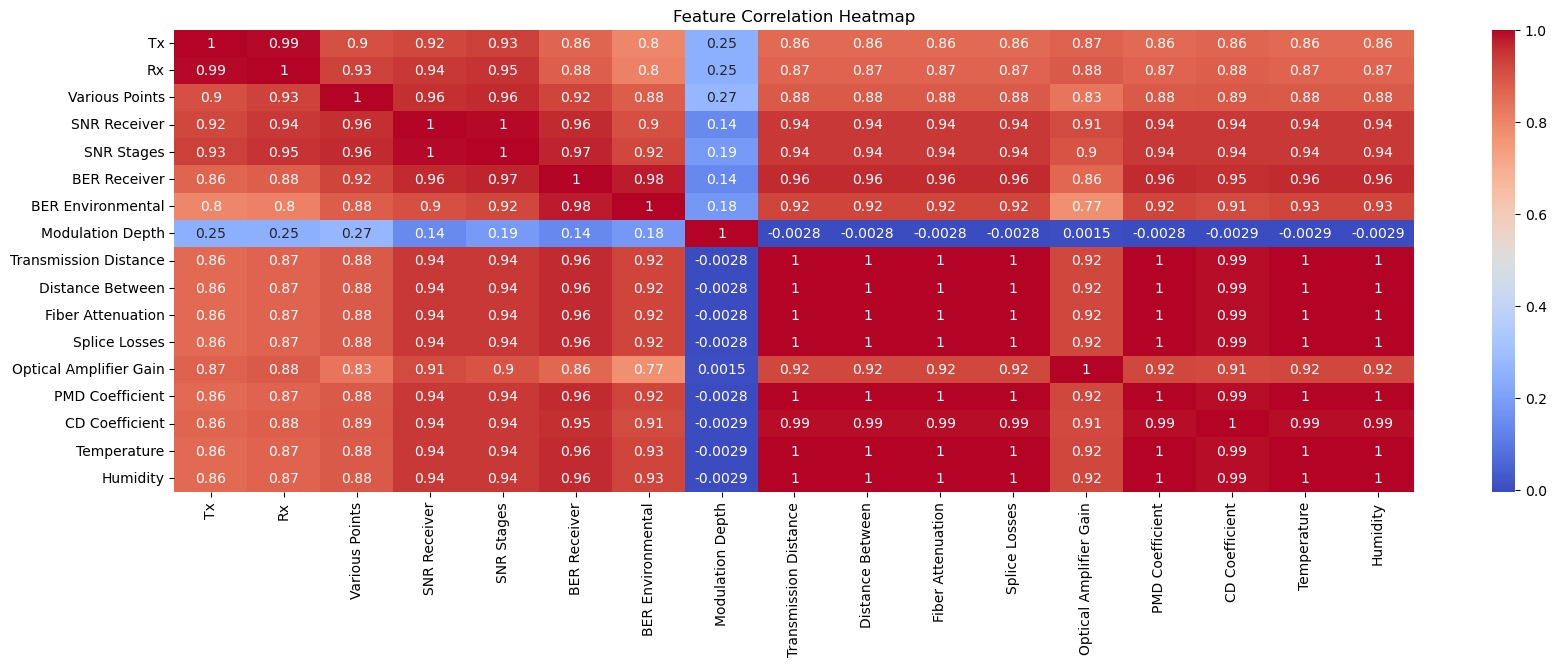

In [78]:
# Correlation heatmap
plt.figure(figsize=(20, 6))

numeric_df = df.select_dtypes(include='number')
sns.heatmap(numeric_df.corr(), cmap="coolwarm", annot = True)

plt.title("Feature Correlation Heatmap")
plt.show()

In [79]:
#Train-Test Splitting
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_resampled,
    y_resampled,
    test_size=0.2,
    random_state=42,
    stratify=y_resampled
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)


Training samples: (860, 20)
Testing samples: (216, 20)


In [80]:
#ML Models Training
from sklearn.naive_bayes import ComplementNB
from sklearn.metrics import accuracy_score, classification_report

# Complement NB requires non-negative values
X_train_nb = X_train - X_train.min()
X_test_nb = X_test - X_test.min()

cnb = ComplementNB()
cnb.fit(X_train_nb, y_train)

y_pred_cnb = cnb.predict(X_test_nb)

print("Complement Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_cnb))
print(classification_report(y_test, y_pred_cnb))

Complement Naive Bayes Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       108
           1       1.00      1.00      1.00       108

    accuracy                           1.00       216
   macro avg       1.00      1.00      1.00       216
weighted avg       1.00      1.00      1.00       216



In [81]:
#B) Support Vector Machine (SVM)
from sklearn.svm import SVC

svm = SVC(kernel='rbf', probability=True)
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))


SVM Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       108
           1       1.00      1.00      1.00       108

    accuracy                           1.00       216
   macro avg       1.00      1.00      1.00       216
weighted avg       1.00      1.00      1.00       216



In [82]:
#C) Linear Discriminant Analysis (LDA)
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

y_pred_lda = lda.predict(X_test)

print("LDA Accuracy:", accuracy_score(y_test, y_pred_lda))
print(classification_report(y_test, y_pred_lda))


LDA Accuracy: 0.9953703703703703
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       108
           1       0.99      1.00      1.00       108

    accuracy                           1.00       216
   macro avg       1.00      1.00      1.00       216
weighted avg       1.00      1.00      1.00       216



In [83]:
#D) Custom Dual-Learner Fusion Architecture (DLFA)
import numpy as np

# Get probability outputs
svm_probs = svm.predict_proba(X_test)
lda_probs = lda.predict_proba(X_test)

# Fusion (average probabilities)
fusion_probs = (svm_probs + lda_probs) / 2

# Final prediction
y_pred_dlfa = np.argmax(fusion_probs, axis=1)

print("DLFA Accuracy:", accuracy_score(y_test, y_pred_dlfa))
print(classification_report(y_test, y_pred_dlfa))

DLFA Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       108
           1       1.00      1.00      1.00       108

    accuracy                           1.00       216
   macro avg       1.00      1.00      1.00       216
weighted avg       1.00      1.00      1.00       216

